# 06_Create_a_Python_AWS_Lambda_Function_with_S3_Upload_Trigger

This note explains **step by step** how to:

1. Create a **Lambda function in Python**
2. Create an **S3 bucket**
3. **Connect S3 as a trigger** to Lambda (on file upload)
4. **Deploy, test, and see logs in CloudWatch**

Along the way we explain **each option** you see on the AWS console pages (from the screenshots & transcript) and what is happening **under the hood**.

---

## 1. Log in & Open the Lambda Service

1. Log in to your **AWS Management Console**.

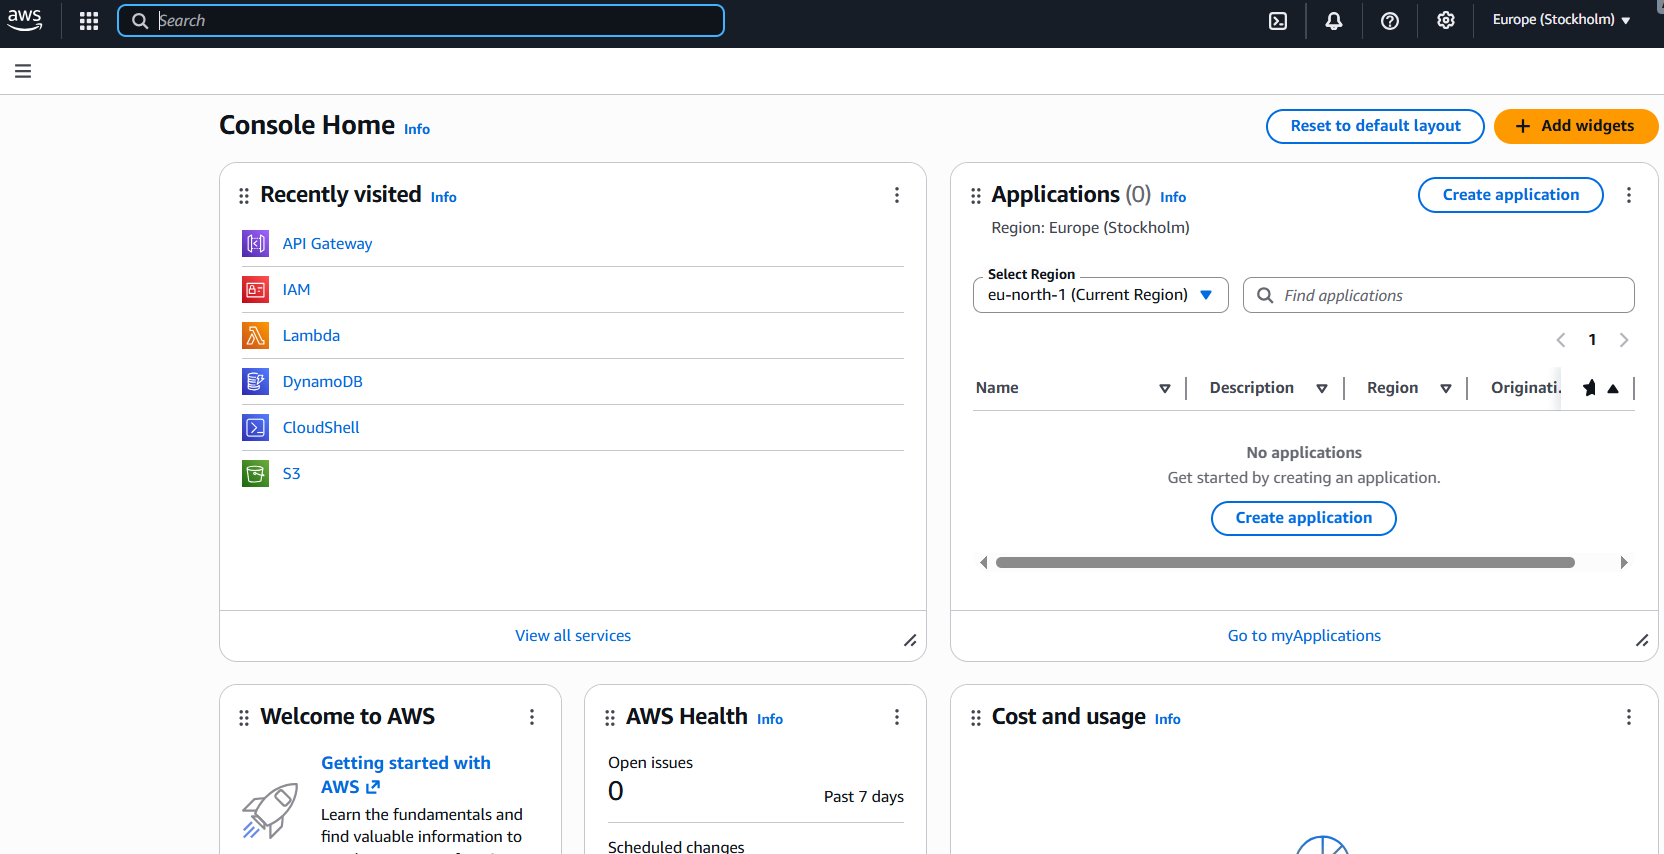


2. On the top search bar, type **“Lambda”**.

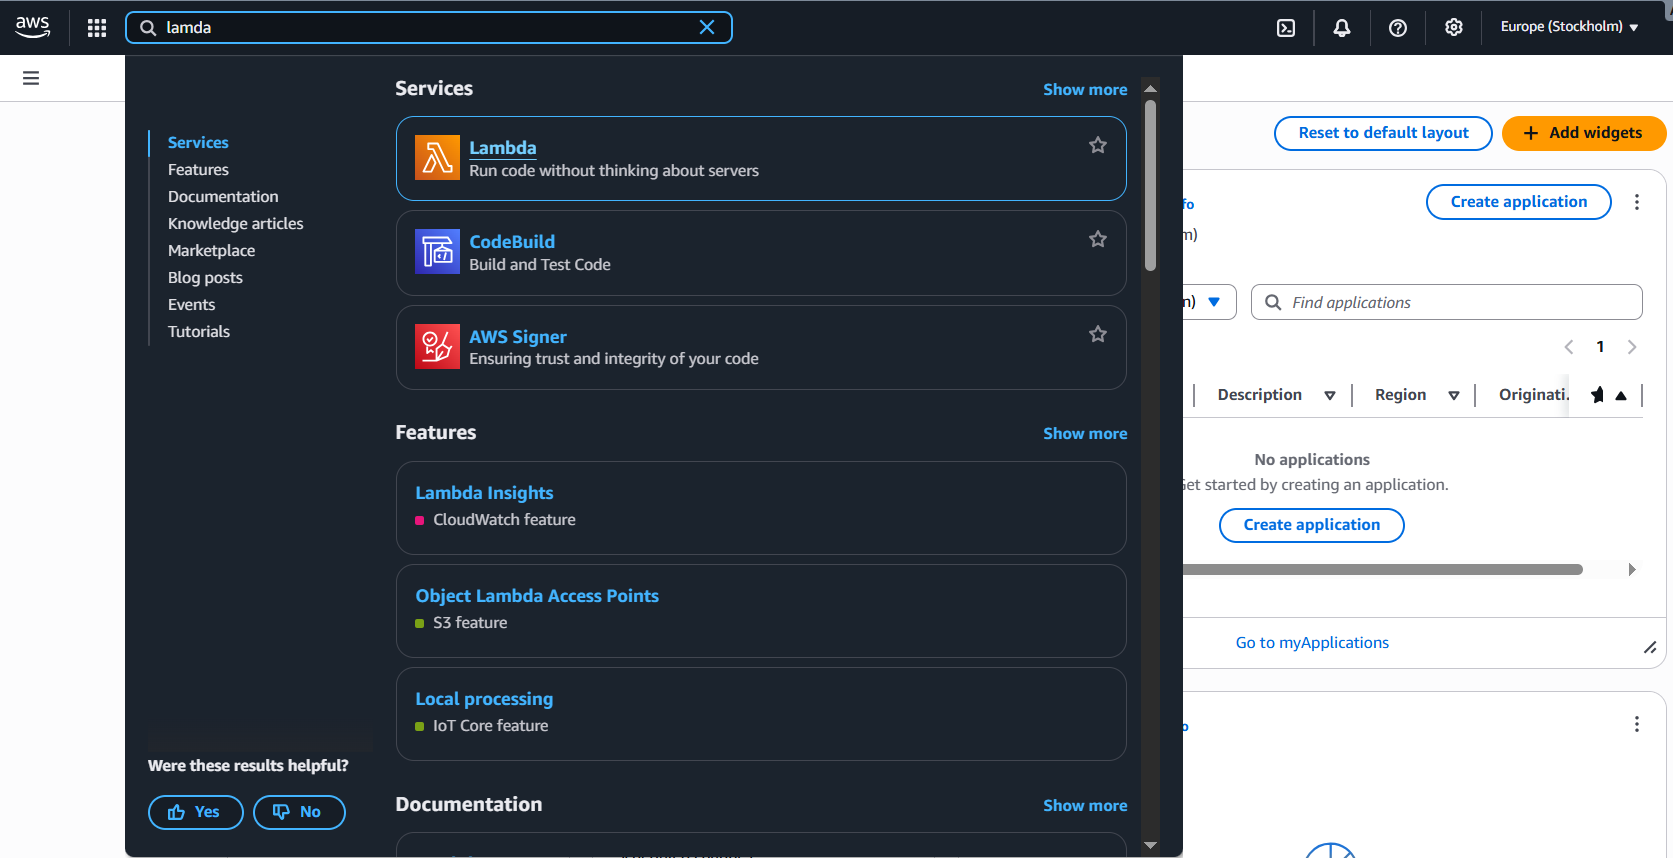


3. Click on **Lambda** (the compute service with the lambda icon).

You’ll land on the Lambda main page where you can manage all functions.

---

## 2. Create a New Lambda Function (Python)

Click **Create function**.

You will see the **“Create function”** page with several options.

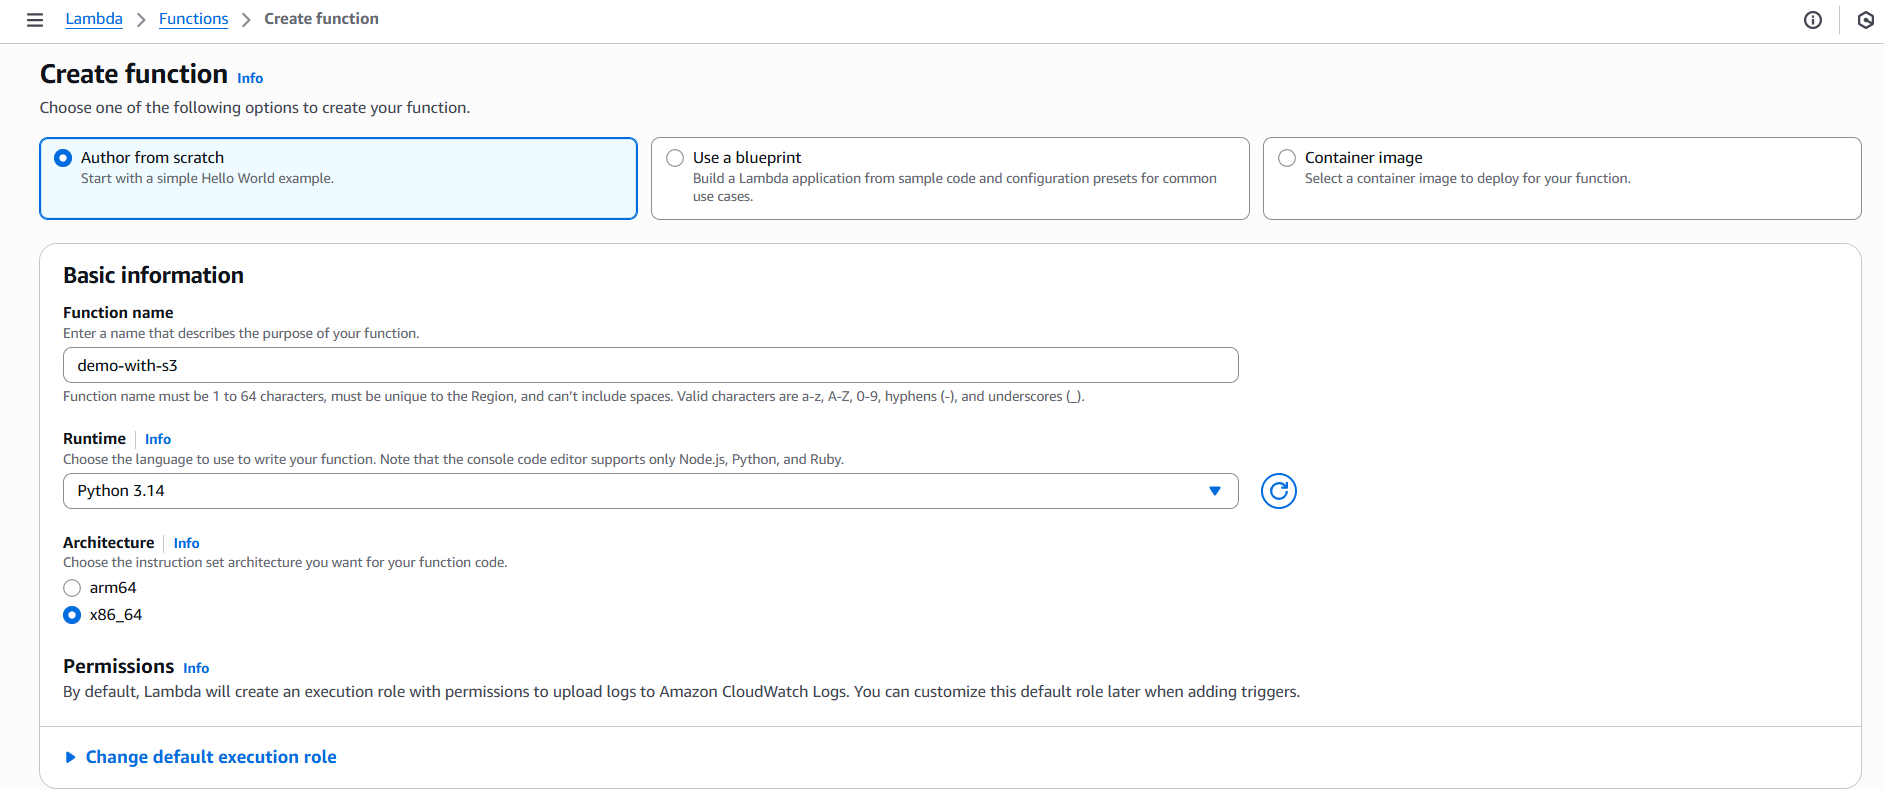

### 2.1 Choose How to Create the Function

**Section: “Choose one of the following options to create your function”**

* **Author from scratch** (selected by default)

  * Start with an empty function and basic hello‑world code.
  * You manually choose name, runtime, permissions.
  * Ideal for learning and small custom functions.

* **Use a blueprint**

  * Predefined templates (examples) for common tasks.
  * Includes code + configuration (e.g., S3 resize image, basic API handler, etc.).
  * Helpful when you know the pattern you want.

* **Container image**

  * Use a Docker container image stored in **ECR (Elastic Container Registry)**.
  * You package your runtime and dependencies into an image.
  * Useful for advanced cases where you need custom OS libs or non‑supported runtimes.

👉 For this tutorial, keep **Author from scratch** selected.

---

### 2.2 Basic Information

You will see the **Basic information** section.

#### (1) Function name

* Example: `demo-with-s3` or `aws-lambda-python-s3`.
* Must be **unique within the region**.
* Allowed characters: letters, numbers, hyphens, and underscores (no spaces).
* Under the hood: this becomes the identifier for your Lambda function and also appears in logs and IAM.

#### (2) Runtime

* Choose the language + version. Example: **Python 3.12** (or Python 3.11/3.10 depending on console).
* This tells Lambda **which runtime environment** to provision:

  * Which interpreter (Python/Node/Java etc.)
  * How to load your handler function
* If you later change the runtime, you must ensure your code is compatible with that version.

#### (3) Architecture

* Common options:

  * `x86_64` – classic Intel/AMD architecture
  * `arm64` – AWS Graviton processors (cheaper and more efficient in many cases)
* For learning, you can keep **x86_64**.
* Under the hood: decides which type of underlying Lambda worker machine runs your code.

#### (4) Permissions (Execution role)

Here you see something like:

* **Permissions** – *By default, Lambda will create an execution role with basic permissions to upload logs to Amazon CloudWatch Logs.*
* Link: **Change default execution role**

If you don’t change anything:

* AWS creates a new **IAM role** for this Lambda
* That role typically has:

  * Permission to **write logs to CloudWatch** (so `print()` or `console.log()` go to log streams)

If you click **Change default execution role**, you’ll see options such as:

* **Create a new role with basic Lambda permissions** (default)
* **Create a new role from AWS policy templates**
* **Use an existing role**

For our simple example, the default new role (with CloudWatch Logs access) is fine. Later, when giving access to S3, Lambda permissions are mostly handled through the **S3 trigger wizard** (it will add invoke permissions + you may also attach S3 access to role if needed).

### 2.3 Create the Function

* Scroll down and click **Create function**.
* AWS will provision:

  * The Lambda configuration (metadata, runtime, handler name)
  * An IAM execution role (if you chose default)
  * A starter **hello‑world** code file (e.g., `lambda_function.py` with a basic handler)

You’ll be taken to the **Function details page**.

---

## 3. Explore the Lambda Function Page

On the function page you normally see:

* **Function overview** (box showing name, ARN, and triggers)
* Tabs: **Code**, **Test**, **Monitor**, **Configuration**, **Aliases**, **Versions**

We focus on:

### 3.1 Code tab

Here you see your main Lambda file:

* For Python, file is typically `lambda_function.py`.
* Contains a default handler function like:

  ```python
  def lambda_handler(event, context):
      return {
          "statusCode": 200,
          "body": "Hello from Lambda!"
      }
  ```

Options inside Code tab:

* **Code source**: built‑in editor or link to upload from a .zip or S3.
* **Deploy** button:

  * After editing code inline, click **Deploy** to save and apply the new version of code.
  * Under the hood: AWS stores a new deployment package for your function.

We will later modify code to add a `print()` message.

---

## 4. Create an S3 Bucket (Event Source)

We now create an S3 bucket that will generate **file‑upload events**.

1. Open a new tab of AWS console.
2. In the search bar, type **S3** and open **S3** service.
3. Click **Create bucket**.

You’ll see the **Create bucket** page.

### 4.1 General configuration

* **AWS Region**

  * Example: `ap-south-1 (Mumbai)`
  * Choose a region **close to your users** / to you for lower latency.
  * Important: **Lambda and S3 bucket must be in the same region** for triggers to work.

* **Bucket type**

  * **General purpose** (recommended)

    * Default bucket type for most workloads. Good for most use cases.
  * **Directory** (seen in newer UI)

    * Treats the bucket more like a directory with some special behavior; generally for specific cases. For now, keep **General purpose**.

* **Bucket name**

  * Example: `aws-py-bucket` or `aws-py-demo-bucket-123`.
  * Must be **globally unique** across all AWS accounts.
  * Must follow S3 naming rules (lowercase, numbers, hyphens, no spaces, etc.).

* **Copy settings from existing bucket (optional)**

  * If you want the same configuration as another bucket.
  * For now, ignore.

### 4.2 Object ownership

Two main modes:

* **ACLs disabled (recommended)**

  * Access control lists (ACLs) are turned off.
  * **All objects in the bucket are owned by the bucket owner account.**
  * Access control is done using **bucket policies** and **IAM policies** only.
  * This is simpler and preferred in modern AWS setups.

* **ACLs enabled**

  * Older method where individual objects can have separate ACL permissions.
  * More complex and not usually needed for simple demos.

👉 For this tutorial, keep **ACLs disabled (recommended)**.

### 4.3 Block public access settings for this bucket

You’ll see several checkboxes such as:

* Block all public access
* Block public access to buckets and objects granted through new ACLs
* Block public access to buckets and objects granted through any ACLs
* Block public access to buckets and objects granted through new public bucket or access point policies

By default, they are **enabled**, meaning **bucket is private**.

If you **uncheck** them, you are allowing possibility for public access.
So that bucket can be accessed publicly if needed. For basic Lambda trigger on file upload, you **do not need public access** – private is fine.

> Under the hood: these checkboxes create guardrail policies that deny any public ACLs or policies. If you uncheck and acknowledge, you can later make bucket objects publicly readable.

* You must confirm by ticking **“I acknowledge…”**.

### 4.4 Other options

* **Bucket Versioning**

  * Enable/Disable versioning for objects.
  * If enabled, every change to a file keeps old versions.
  * Not required for this example → you can leave default.

* **Tags (optional)**

  * Key–value pairs to label your bucket, e.g., `Project=LambdaDemo`.
  * Useful for cost tracking and organization.

* **Default encryption**

  * Choose whether S3 automatically encrypts objects at rest.
  * Options: SSE-S3, SSE-KMS, or none.
  * For simple demos, default is usually fine.

You can leave these at default for now.

### 4.5 Create bucket

* Scroll to the bottom and click **Create bucket**.
* Your bucket will now appear in the list.

---

## 5. Connect Lambda and S3 – Add Trigger

Now we make S3 **trigger** our Lambda function whenever a file is uploaded.

### 5.1 Go back to the Lambda Function

1. Go to the **Lambda console**.
2. Open the function you created (`demo-with-s3`).

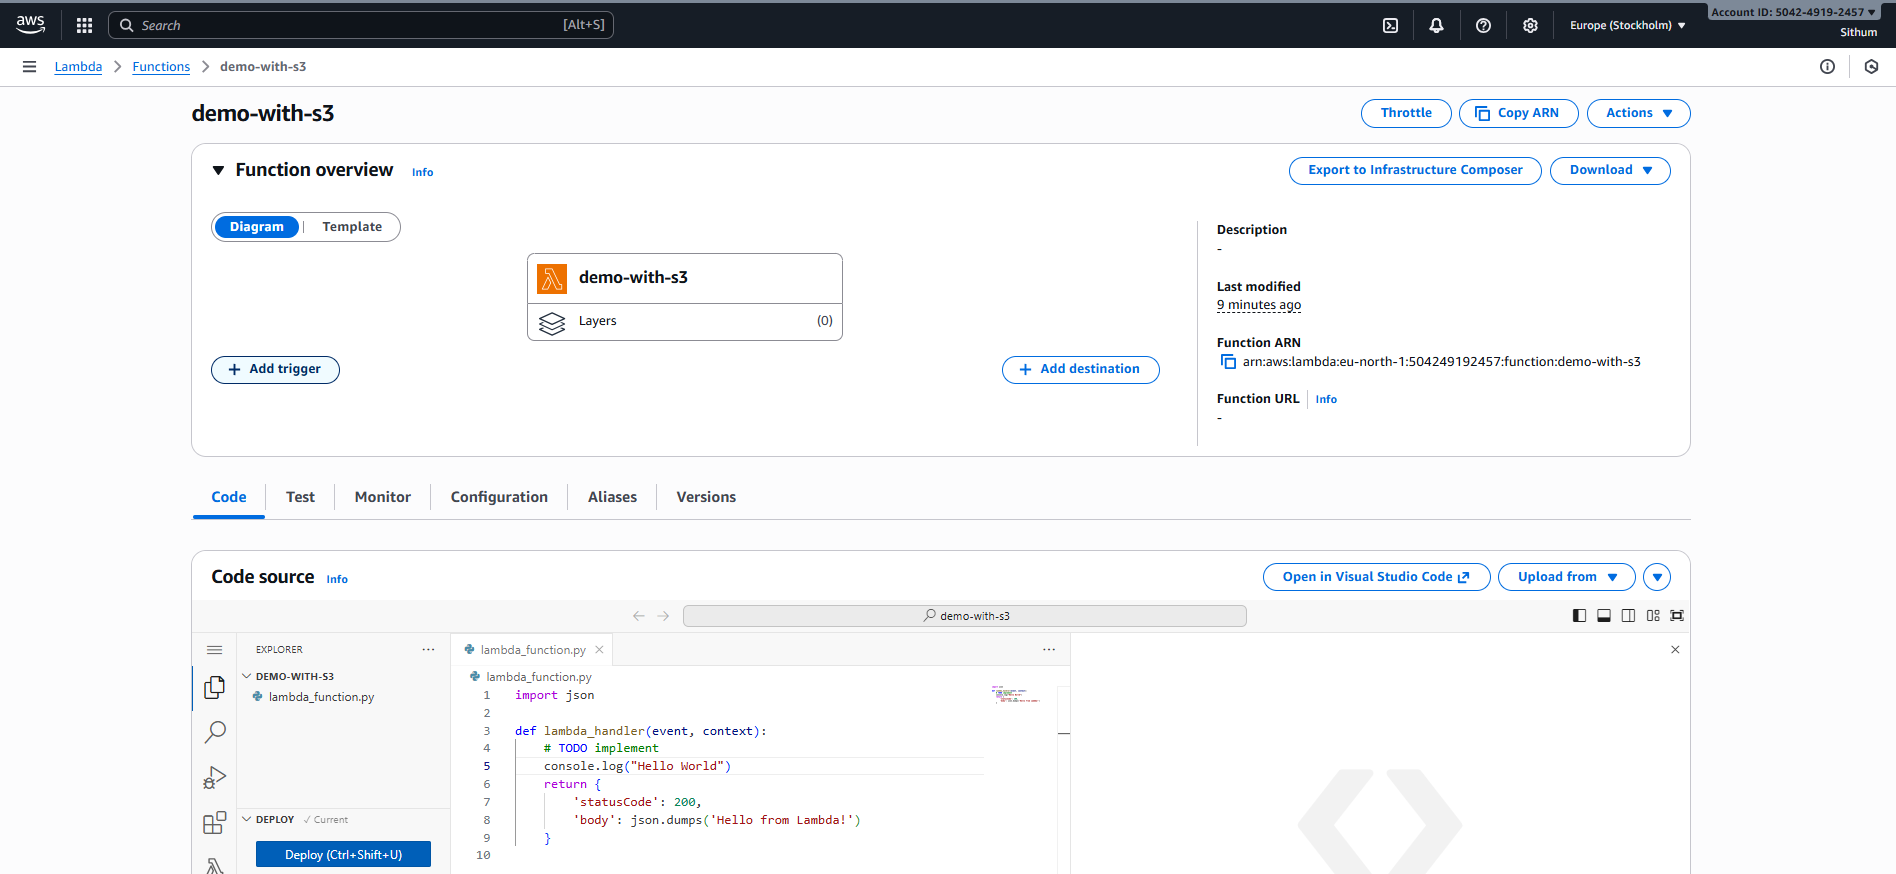

3. In the **Function overview** section, click **+ Add trigger**.

You’ll see the **Add trigger** configuration page.

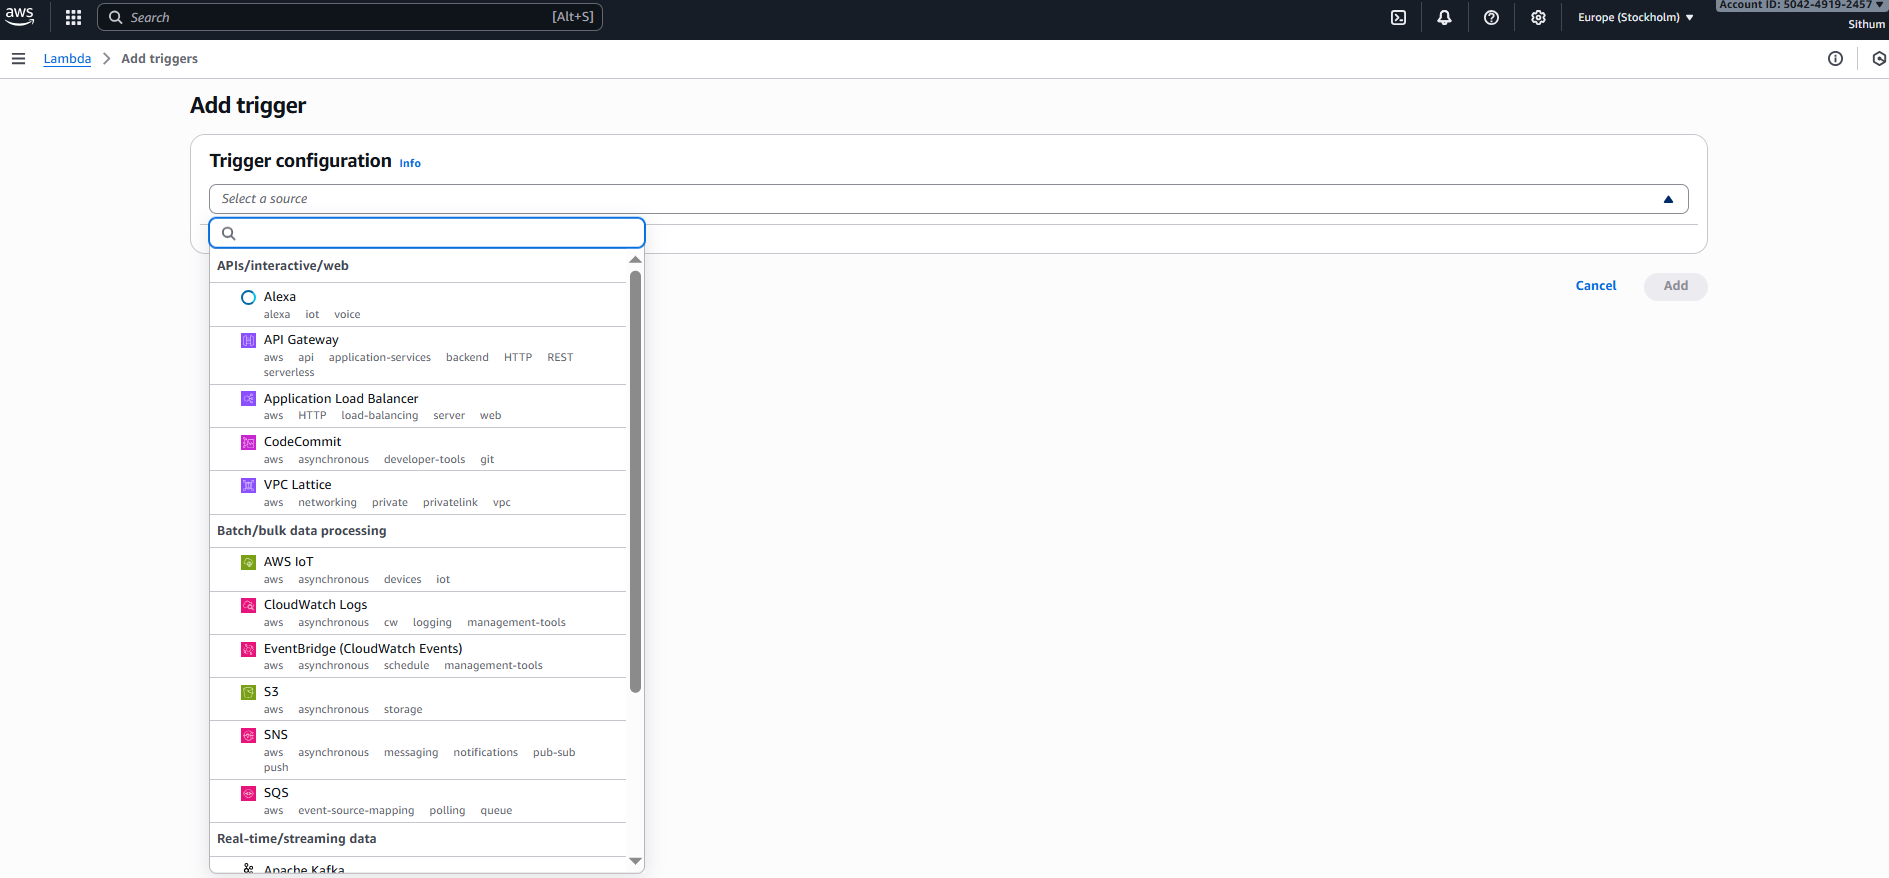

### 5.2 Trigger configuration – Selecting S3

* **Trigger configuration (source)**

  * Dropdown called **Select a source**.
  * Shows multiple services:

    * API Gateway (for HTTP/APIs)
    * S3
    * DynamoDB
    * SNS
    * SQS
    * EventBridge, etc.

Select **S3**.

Now more options appear related to S3.

### 5.3 Choose the Bucket

* **Bucket**

  * Select your previously created bucket (e.g., `aws-py-bucket`).
  * Lambda and bucket must be in **same region**.

Under the hood, this links S3 events for that bucket to the Lambda function.

### 5.4 Event type – When Should It Trigger?


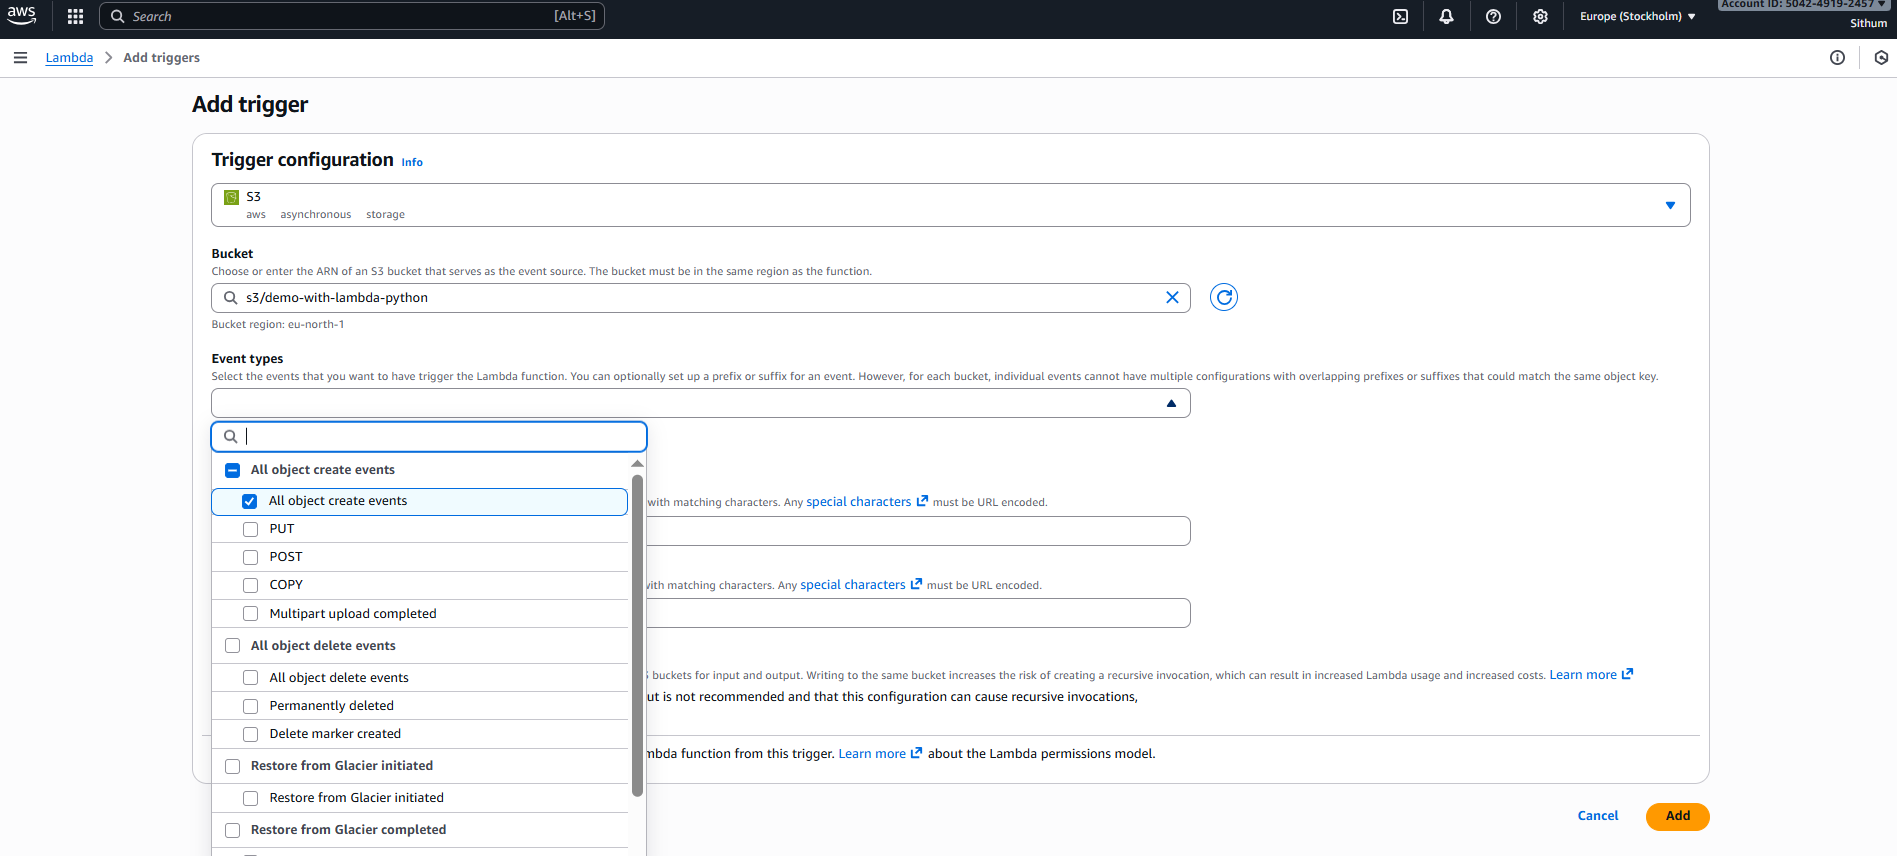

* **Event type** dropdown (from screenshot):

  * Options include:

    * All object create events
    * PUT
    * POST
    * COPY
    * Multipart upload completed
    * All object delete events
    * Restore completed, etc.

For our use case, choose **All object create events**.

This means:

* Whenever an object is created (uploaded, copied, or completed multipart upload) in the bucket, S3 sends an **event notification** to Lambda.

**Under the hood:**

* S3 creates an **event notification configuration** on the bucket.
* For each object create event, S3 sends a JSON event to Lambda containing:

  * Bucket name
  * Object key (file path)
  * Size, etc.

### 5.5 (Optional) Prefix / Suffix Filters

In the UI you may see fields like:

* **Prefix** – trigger only if object key starts with this path (e.g., `images/`).
* **Suffix** – trigger only if file name ends with extension (e.g., `.jpg`).

These are optional and not used in the transcript, but good to know:

* Example: prefix `uploads/` and suffix `.png` → only upload of `.png` files inside `uploads/` folder triggers Lambda.

### 5.6 Recursive invocation protection

There is a checkbox **“Recursive invocations”** or similar description:

* Warning: *“Using the same S3 bucket for both input and output is not recommended because it can cause recursive invocations.”*

Meaning:

* If your Lambda function writes **output files back to the same bucket** which triggers it, you may create an **infinite loop**:

  * File uploaded → triggers Lambda → Lambda writes another file → triggers Lambda again → etc.

Ticking the checkbox is an acknowledgment that you are aware of this risk. For our simple read‑only example, we are safe, but it’s good practice to:

* Use **separate buckets** for input and output, or
* Use prefixes/filters so Lambda doesn’t react to its own outputs.

### 5.7 Permissions (What AWS Does Automatically)

When you click **Add**:

* AWS updates the **S3 bucket configuration** with an **event notification**.
* AWS updates IAM permissions so that **S3 is allowed to invoke your Lambda function** (adds permission to Lambda resource policy).

Now the trigger will be visible in the **Function overview** diagram.

---

## 6. Edit and Deploy Lambda Code (Python)

### 6.1 Open Code Tab

1. On the Lambda function page, click the **Code** tab.
2. You see the Python file, e.g. `lambda_function.py`.

### 6.2 Simple Code Example with Log Message

You can modify the handler to something like:

```python
import json


def lambda_handler(event, context):
    message = "Welcome to AWS Lambda function using Python"
    print(message)  # This goes to CloudWatch Logs

    # (Optional) print event details to understand structure
    print("Event received:", json.dumps(event))

    return {
        "statusCode": 200,
        "body": json.dumps({"message": message})
    }
```

### 6.3 Deploy the Code

* After editing, click **Deploy**.
* This publishes the latest code version for future invocations.

Under the hood:

* Lambda stores a new version of your deployment package (code + dependencies, if any).

---

## 7. Test by Uploading a File to S3

Now we verify that the trigger works.

### 7.1 Open S3 Bucket and Upload

1. Go to **S3** → open your bucket.
2. Click **Upload**.
3. On the upload page:

   * Click **Add files**
   * Choose a file from your computer (e.g., `data1.jpg`)
   * Click **Upload**.

After a few seconds, you should see **“Upload succeeded”** and the file listed in the bucket.

### 7.2 What Happens Under the Hood

1. File is uploaded and stored in S3.
2. S3 detects this **object create event**.
3. S3 checks the bucket’s event notification configuration.
4. It finds a rule: **for all object create events, invoke this Lambda function**.
5. S3 sends a **JSON event** to Lambda containing bucket name, key, etc.
6. Lambda runtime starts a new execution environment (if needed) and calls your `lambda_handler(event, context)`.
7. Your code runs, prints messages, then exits.
8. Logs are streamed to **CloudWatch Logs**.

---

## 8. View Metrics & Logs (Monitor Tab + CloudWatch)

### 8.1 Lambda Monitor Tab

On the Lambda function page:

1. Click the **Monitor** tab.
2. You will see **CloudWatch metrics** such as:

   * **Invocations** – number of times Lambda ran
   * **Duration** – execution time
   * **Errors** – how many failures occurred
   * **Throttles** – how many times execution was limited due to concurrency limits
   * **Concurrent executions**

After uploading files, refresh to see metrics update. The **invocation count** should increase with each upload.

### 8.2 Open CloudWatch Logs

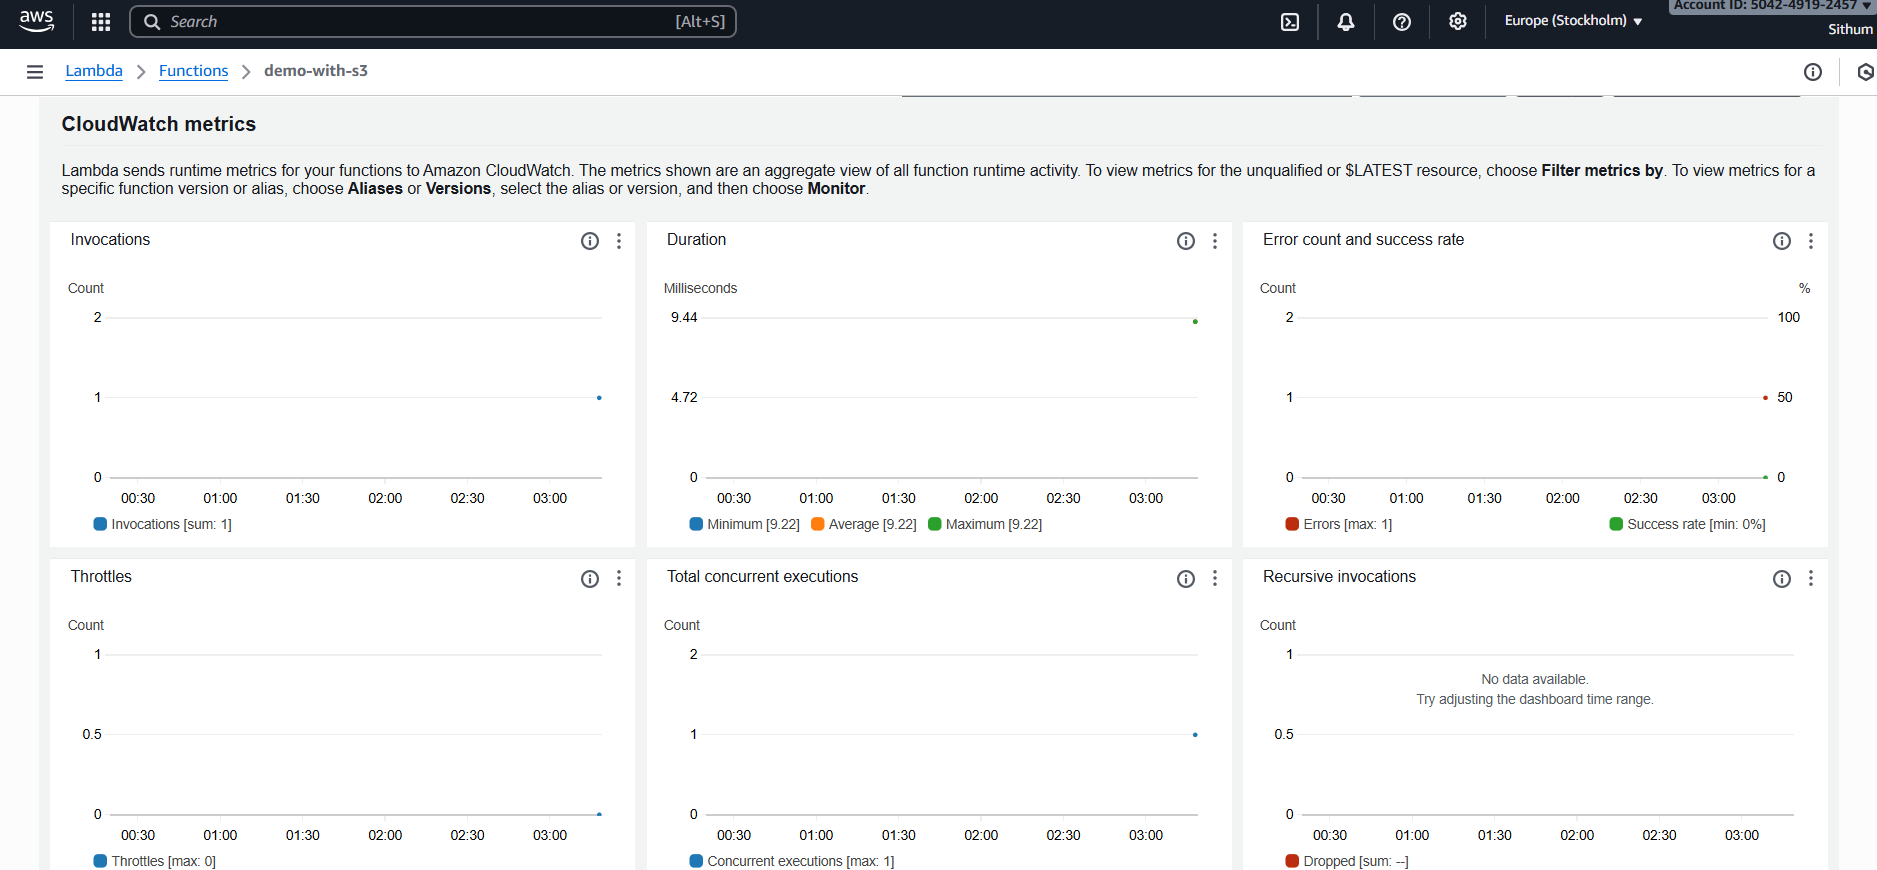

From Monitor tab, there’s a link **View logs in CloudWatch** (or **CloudWatch logs**).

1. Click the link – it opens the **CloudWatch Logs** console.
2. You’ll see a **log group** named like `/aws/lambda/demo-with-s3`.
3. Inside the log group, there are **log streams** for each execution environment.
4. Click the latest log stream → you’ll see log events including:

   * START / END / REPORT lines (Lambda system info)
   * Your `print()` output, e.g.

     * `Welcome to AWS Lambda function using Python`
     * `Event received: { ... }`

If there is an error (e.g., variable typo), you’ll see the **stack trace** here.

---

## 9. End‑to‑End Flow Summary

1. **Create Lambda function (Python)** using *Author from scratch*.
2. **Provide name, runtime, architecture, permissions**.
3. **Create S3 bucket** (region = same as Lambda, choose general purpose, object ownership and public access as needed).
4. In Lambda, **Add trigger**:

   * Source: **S3**
   * Bucket: your bucket
   * Event type: **All object create events**
   * (Optionally configure prefix/suffix filters)
   * Acknowledge recursive invocation warning if using same bucket for output.
5. **Write/modify Python code**, add `print()` for logging, then **Deploy**.
6. **Upload files** to S3 bucket.
7. S3 triggers Lambda → Lambda runs code → logs go to **CloudWatch**.
8. Use **Monitor** tab and **CloudWatch Logs** to see invocations, debug, and confirm everything works.

With this, you now understand **both the step‑by‑step UI** and **what’s happening behind the scenes** when you connect an S3 upload event to a Python Lambda function.
